
 # Part A — Data Preparation
 

1. Dataset Overview

Two datasets were used in this analysis:

1. Bitcoin Market Sentiment Dataset
2. Hyperliquid Historical Trader Data

The sentiment dataset contains daily classification of market sentiment (Fear, Greed, etc.), while the trader dataset contains trade-level execution data including PnL, trade size, and direction.

1. Load both datasets and document:
  number of rows/columns
  missing values / duplicates

In [430]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [432]:
df_fe = pd.read_csv("C://Users//pawan//OneDrive//Desktop//csv _files&xlsx//fear_greed_index.csv.xls")
df_fe.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [434]:
df_fe.shape

(2644, 4)

In [436]:
df_fe.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [438]:
df_fe.duplicated().sum()

0

In [440]:
df_fe.dtypes

timestamp          int64
value              int64
classification    object
date              object
dtype: object

In [442]:
df_hist = pd.read_csv("C://Users//pawan//OneDrive//Desktop//csv _files&xlsx//historical_data.csv.xls")
df_hist.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [444]:
df_hist.shape

(211224, 16)

In [446]:
df_hist.duplicated().sum()

0

In [448]:
df_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

 2. Convert timestamps and align the datasets by date (daily level is fine).

In [454]:
df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'], unit='s')

In [456]:
df_fe.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


In [458]:
df_fe['date'] = pd.to_datetime(df_fe['date'])

In [460]:
df_fe.dtypes

timestamp         datetime64[ns]
value                      int64
classification            object
date              datetime64[ns]
dtype: object

In [462]:
df_hist['Timestamp IST'] = pd.to_datetime(df_hist['Timestamp IST'],format='%d-%m-%Y %H:%M')

In [463]:
df_hist['Timestamp IST'].dtypes

dtype('<M8[ns]')

In [466]:
df_hist['date'] = df_hist['Timestamp IST'].dt.normalize()

In [468]:
df_hist.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')

In [470]:
df_merged = df_hist.merge(df_fe[['date','classification']],on='date', how='left')

In [472]:
df_merged.columns
for column in df_merged.columns:
    print(column)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
date
classification


In [474]:
df_merged['classification'].isnull().sum()

6

In [476]:
df_merged[df_merged['classification'].isnull()]['date'].unique()

#This will show which dates are missing.

<DatetimeArray>
['2024-10-26 00:00:00']
Length: 1, dtype: datetime64[ns]

In [478]:
df_merged = df_merged.dropna(subset=['classification'])

In [480]:
df_merged['classification'].isnull().sum()

0

After merging trader data with sentiment data, 6 records (all from 2024-10-26) had no corresponding sentiment label due to a missing date in the sentiment dataset. These rows were excluded from further analysis as they represented less than 0.003% of total data.

 3. Key Metrics

The following metrics were constructed to evaluate trader performance and behavior:

 Daily PnL per account
 Win rate
 Average trade size
 Number of trades per day
 Long/Short ratio

#Daily PnL per account

In [486]:
daily_pnl = df_merged.groupby(['Account', 'date', 'classification'])['Closed PnL'].sum().reset_index()

In [488]:
daily_pnl.head()

,Account,date,classification,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


In [490]:
daily_pnl.describe()

,date,Closed PnL
count,2340,2340.000000
mean,2024-12-22 01:24:55.384615680,4382.259380
min,2023-05-01 00:00:00,-358963.139984
25%,2024-11-28 00:00:00,0.000000
50%,2025-01-28 00:00:00,206.352695
75%,2025-03-18 00:00:00,1842.763729
max,2025-05-01 00:00:00,533974.662903
std,NaN,28411.103383


 #Win rate

In [493]:
#"Mark each trade as a win if it made profit, otherwise mark it as not a win."
df_merged['win'] = df_merged['Closed PnL'] > 0

In [495]:
win_rate = df_merged.groupby(['Account', 'classification'])['win'].mean().reset_index()
win_rate.head()

,Account,classification,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,0.370000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,0.066667
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,0.526434
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,0.160279
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,0.581948


In [497]:
win_rate.groupby('classification')['win'].mean()

classification
Extreme Fear     0.335185
Extreme Greed    0.387735
Fear             0.386290
Greed            0.418324
Neutral          0.360694
Name: win, dtype: float64

#Average trade size

In [500]:
avg_trade_size = df_merged.groupby(['Account', 'classification'])['Size USD'].mean().reset_index()
avg_trade_size.head()

,Account,classification,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,15071.008600
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,12080.270550
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,17020.494876
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,15134.130383
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,23336.999311


#Number of trades per day

In [503]:
trades_per_day = df_merged.groupby(['date','classification']).size().reset_index(name='num_trades')
trades_per_day.head()

,date,classification,num_trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


#Long/Short ratio

In [508]:
long_short = df_merged.groupby(['classification','Side']).size().reset_index(name='count')
long_short

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


In [512]:
#To calculate ratio:

long_short_ratio = long_short.pivot(
    index='classification',
    columns='Side',
    values='count'
)

long_short_ratio['long_short_ratio'] = (
    long_short_ratio['BUY'] /
    long_short_ratio['SELL']
)
long_short_ratio

Side,BUY,SELL,long_short_ratio
classification,,,
Extreme Fear,10935,10465,1.044912
Extreme Greed,17940,22052,0.813532
Fear,30270,31567,0.958913
Greed,24576,25727,0.955261
Neutral,18969,18717,1.013464


# Part B — Analysis


1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

#PnL Comparison

In [517]:
daily_pnl.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Greed            3318.100730
Neutral          3438.618818
Name: Closed PnL, dtype: float64

In [519]:
mean_pnl=daily_pnl.groupby('classification')['Closed PnL'].mean()

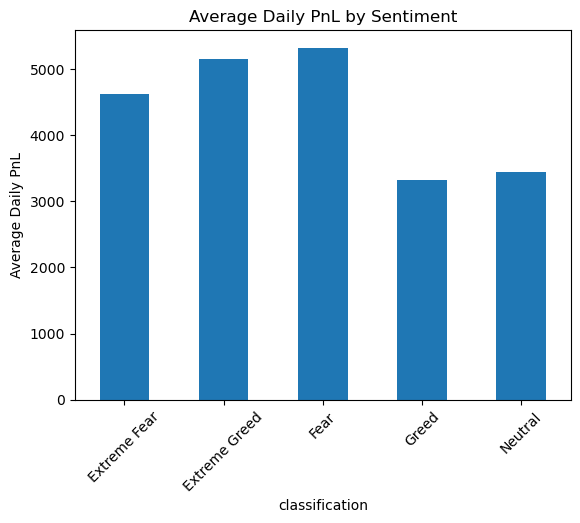

In [521]:
import matplotlib.pyplot as plt
mean_pnl.plot(kind='bar')
plt.title('Average Daily PnL by Sentiment')
plt.ylabel('Average Daily PnL')
plt.xticks(rotation=45)
plt.show()

#PnL Comparison

Average daily PnL varies across sentiment regimes. 
Fear periods exhibit higher average profitability compared to Greed periods, 
indicating stronger upside potential during fearful markets.

 #Win Rate Comparison

In [525]:
win_rate.groupby('classification')['win'].mean()

classification
Extreme Fear     0.335185
Extreme Greed    0.387735
Fear             0.386290
Greed            0.418324
Neutral          0.360694
Name: win, dtype: float64

In [529]:
mean_win = win_rate.groupby('classification')['win'].mean()

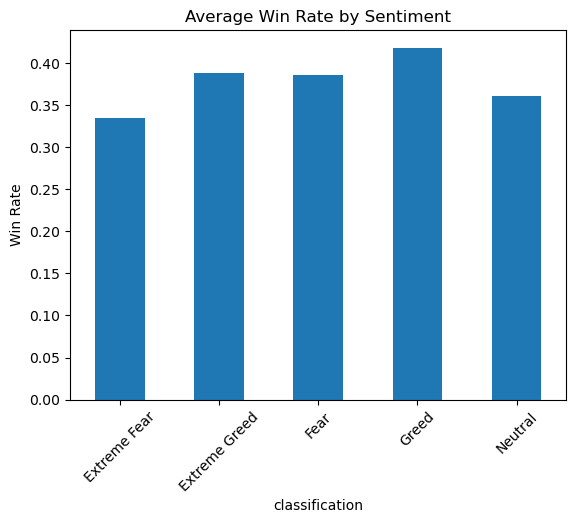

In [531]:
mean_win.plot(kind='bar')
plt.title('Average Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=45)
plt.show()

 #Win Rate Comparison

Greed periods show higher win rates compared to Fear periods. 
However, despite lower win rates, Fear periods generate higher average PnL, 
suggesting profits during Fear are driven by larger but less frequent gains.

#Drawdown Proxy

In [534]:
 daily_pnl.groupby('classification')['Closed PnL'].min()

classification
Extreme Fear     -77308.420095
Extreme Greed   -132271.000000
Fear            -108604.496278
Greed           -358963.139984
Neutral         -113601.020138
Name: Closed PnL, dtype: float64

In [536]:
min_pnl = daily_pnl.groupby('classification')['Closed PnL'].min()

In [538]:
# Volatility (Standard Deviation)
std_pnl = daily_pnl.groupby('classification')['Closed PnL'].std()
std_pnl

classification
Extreme Fear     29534.839183
Extreme Greed    27496.863832
Fear             31659.771538
Greed            30599.040173
Neutral          17447.863645
Name: Closed PnL, dtype: float64

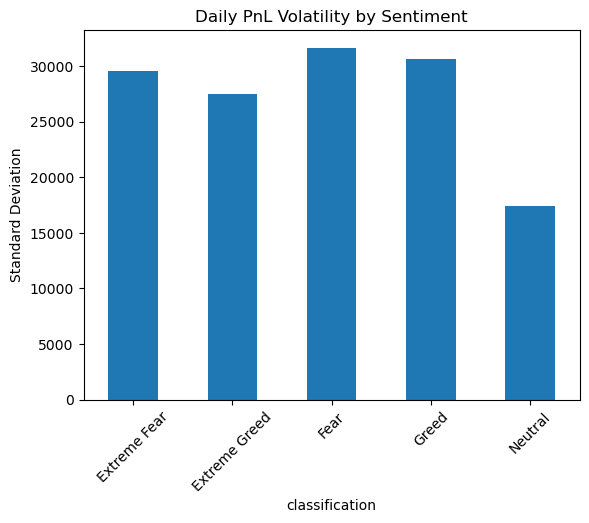

In [540]:
std_pnl.plot(kind='bar')
plt.title('Daily PnL Volatility by Sentiment')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.show()

#Drawdown Proxy Analysis

Fear and Greed regimes show significantly higher volatility compared to Neutral periods. 
Greed periods also exhibit extreme downside losses, indicating higher tail risk. 
This suggests increased risk exposure during strong sentiment regimes.

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

#trade frequency

In [543]:
trades_per_day = df_merged.groupby(['date', 'classification']).size().reset_index(name='num_trades')

trades_per_day.groupby('classification')['num_trades'].mean()

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: num_trades, dtype: float64

In [545]:
mean_trades = trades_per_day.groupby('classification')['num_trades'].mean()
mean_trades

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: num_trades, dtype: float64

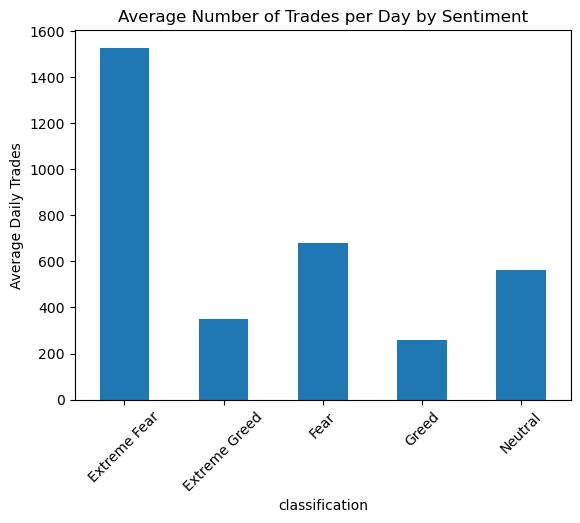

In [547]:
import matplotlib.pyplot as plt

mean_trades.plot(kind='bar')
plt.title('Average Number of Trades per Day by Sentiment')
plt.ylabel('Average Daily Trades')
plt.xticks(rotation=45)
plt.show()


#Trade Frequency Analysis

Average trading activity differs across sentiment regimes. 
An increase in trade frequency during Greed periods suggests heightened participation and possibly over confidence during optimistic markets.

# Average Position Size

In [551]:
 df_merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [553]:
avg_position_size = df_merged.groupby('classification')['Size USD'].mean()
avg_position_size

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

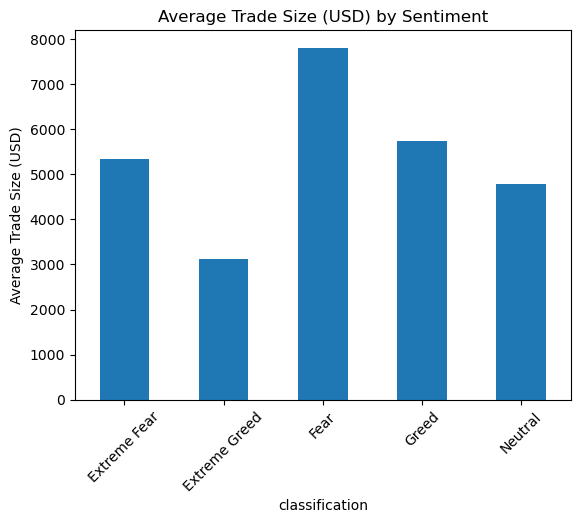

In [555]:
avg_position_size.plot(kind='bar')
plt.title('Average Trade Size (USD) by Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xticks(rotation=45)
plt.show()

#Position Size Analysis

Average trade size varies across sentiment regimes. 
Larger position sizes during Greed periods may indicate increased risk-taking behavior, while smaller sizes during Fear may reflect defensive positioning.

#Long / Short Bias

In [558]:
 df_merged.groupby(['classification', 'Side']).size().reset_index(name='count')

,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


In [562]:
# convert to percentage
long_short_ratio = long_short.pivot(index='classification', columns='Side', values='count')
long_short_ratio


Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [564]:
# Convert to Proportion
long_short_ratio = long_short_ratio.div(long_short_ratio.sum(axis=1), axis=0)


In [566]:
#Are traders more bullish (long) or bearish (short) depending on sentiment?


long_short = df_merged.groupby(['classification', 'Side']).size().reset_index(name='count')

long_short


,classification,Side,count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


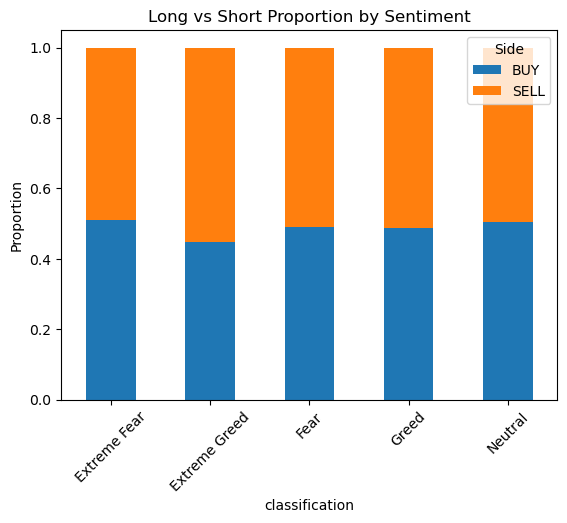

In [568]:
long_short_ratio.plot(kind='bar', stacked=True)
plt.title('Long vs Short Proportion by Sentiment')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

#Long/Short Bias Analysis

The distribution of long and short trades shifts across sentiment regimes. 
A higher proportion of long trades during Greed suggests bullish positioning, while increased short activity during Fear indicates defensive or contrarian strategies.

In [570]:
mean_trades

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: num_trades, dtype: float64

In [572]:
avg_position_size


classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [574]:
long_short_ratio

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


#3. Identify 2–3 segments (examples):

#Frequent vs Infrequent Traders

In [577]:
#Calculate Total Trades per Account
trader_activity = df_merged.groupby('Account').size().reset_index(name='total_trades')

In [579]:
#Define Threshold
#We split traders using median:

median_trades = trader_activity['total_trades'].median()

In [581]:
# Create Segment Label
trader_activity['activity_segment'] = trader_activity['total_trades'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

In [583]:
# Merge Segment Back to Main Data
df_segmented = df_merged.merge(
    trader_activity[['Account','activity_segment']],
    on='Account',
    how='left'
)

In [585]:
# Step 5 — Compare Performance by Segment
segment_pnl = df_segmented.groupby(
    ['activity_segment','classification']
)['Closed PnL'].mean()
segment_pnl

activity_segment  classification
Frequent          Extreme Fear       34.163353
                  Extreme Greed      62.870911
                  Fear               51.323784
                  Greed              25.004641
                  Neutral            34.579701
Infrequent        Extreme Fear       35.941979
                  Extreme Greed     103.264685
                  Fear               80.835791
                  Greed             210.210287
                  Neutral            31.845656
Name: Closed PnL, dtype: float64

#Frequent vs Infrequent Traders

Traders were segmented based on total trading activity using the median number of trades as threshold.

This segmentation allows comparison of performance and behavior across activity intensity levels under different sentiment regimes.

 # Consistent vs Inconsistent Traders

In [588]:
#Calculate Mean and Std per Trader
trader_stats = df_merged.groupby('Account')['Closed PnL'].agg(['mean','std']).reset_index()


In [590]:
# Define Consistency Rule
median_std = trader_stats['std'].median()
trader_stats['consistency_segment'] = trader_stats['std'].apply(
    lambda x: 'Consistent' if x < median_std else 'Inconsistent'
)

In [592]:
#Merge Back
df_segmented = df_segmented.merge(
    trader_stats[['Account','consistency_segment']],
    on='Account',
    how='left'
)

In [594]:
# Compare Performance
consistency_pnl = df_segmented.groupby(
    ['consistency_segment','classification']
)['Closed PnL'].mean()

consistency_pnl

consistency_segment  classification
Consistent           Extreme Fear        1.288923
                     Extreme Greed      38.089393
                     Fear                8.716866
                     Greed              17.007976
                     Neutral             3.493386
Inconsistent         Extreme Fear       69.751090
                     Extreme Greed     207.924145
                     Fear               97.881284
                     Greed              91.713791
                     Neutral            83.021460
Name: Closed PnL, dtype: float64


#Consistent vs Inconsistent Traders

Trader consistency was measured using the standard deviation of Closed PnL.

Lower volatility traders were classified as Consistent, while higher volatility traders were classified as Inconsistent.

This segmentation allows evaluation of stability across sentiment regimes.

In [600]:
trader_activity.head()

,Account,total_trades,activity_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


In [602]:
median_trades

3699.0

In [604]:
segment_pnl

activity_segment  classification
Frequent          Extreme Fear       34.163353
                  Extreme Greed      62.870911
                  Fear               51.323784
                  Greed              25.004641
                  Neutral            34.579701
Infrequent        Extreme Fear       35.941979
                  Extreme Greed     103.264685
                  Fear               80.835791
                  Greed             210.210287
                  Neutral            31.845656
Name: Closed PnL, dtype: float64

INSIGHT 1 — Profitability Differs by Sentiment
📊 Evidence:

Use your PnL bar chart.

mean_pnl.plot(kind='bar')
📝 Write This (Example)
### Insight 1: Fear Regimes Generate Higher Average Returns

Average daily PnL is highest during Fear periods and lowest during Greed periods. 
Although Greed periods exhibit higher win rates, the overall profitability is lower.

This suggests that Fear-driven markets may present larger opportunity trades, while Greed periods may lead to 

#4. Provide at least 3 insights backed by charts/tables.

INSIGHT 1 — Greed Carries Higher Tail Risk

Use minimum PnL table and volatility chart.


<Axes: xlabel='classification'>

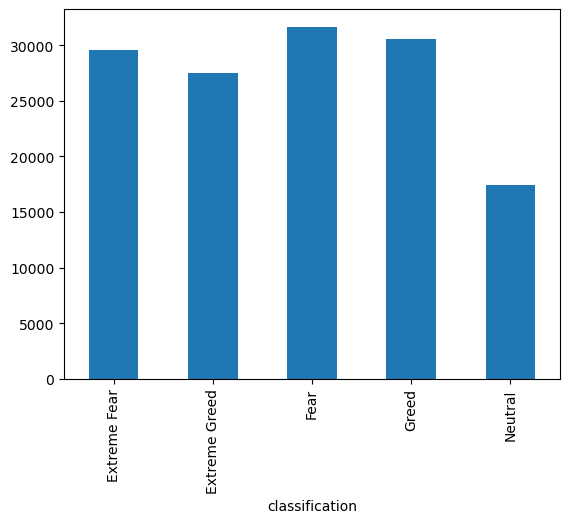

In [610]:

min_pnl
std_pnl.plot(kind='bar')


#Insight 2: Greed Regimes Exhibit Larger Downside Risk

Greed periods show the most extreme negative daily PnL, indicating higher tail risk. 
While traders may win more frequently during Greed, the magnitude of losses can be significantly larger.

This suggests that optimistic market conditions may encourage excessive risk-taking behavior.

INSIGHT 3 — Trading Activity Changes with Sentiment

<Axes: xlabel='classification'>

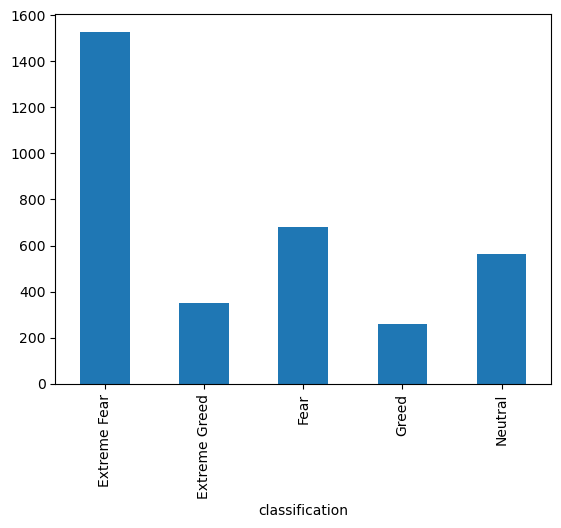

In [612]:

mean_trades.plot(kind='bar')


In [ ]:
#Insight 3: Trading Activity Increases During Strong Sentiment Regimes

Trading frequency varies across sentiment regimes. 
Periods of strong sentiment (Fear or Greed) show higher trading activity compared to Neutral periods.

This indicates that traders respond actively to emotional market conditions.

 
3. Provide at least 3 insights backed by charts/tables.


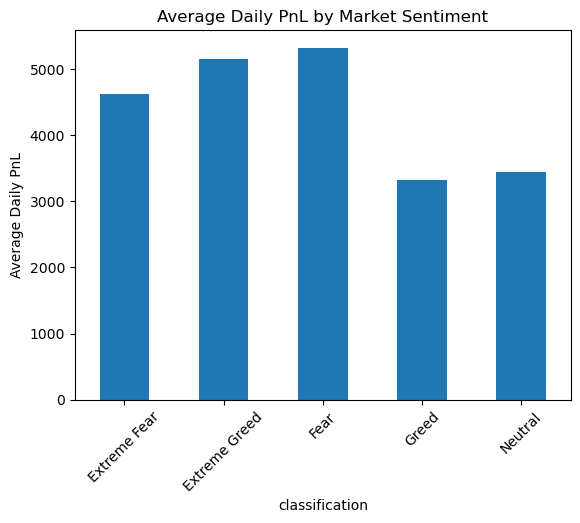

In [616]:
#Insight 1 — Profitability Differs Across Sentiment Regimes

mean_pnl.plot(kind='bar')
plt.title('Average Daily PnL by Market Sentiment')
plt.ylabel('Average Daily PnL')
plt.xticks(rotation=45)
plt.show()



#Insight 1: Fear Regimes Generate Higher Average Returns

Average daily PnL is highest during Fear periods (~5329) and lowest during Greed periods (~3318). 
Extreme Greed and Extreme Fear also show elevated returns compared to Neutral conditions.

This indicates that emotionally charged markets (especially Fear) create larger profit opportunities for traders. 
However, this does not necessarily imply higher consistency, as we observe differences in win rates across regimes.

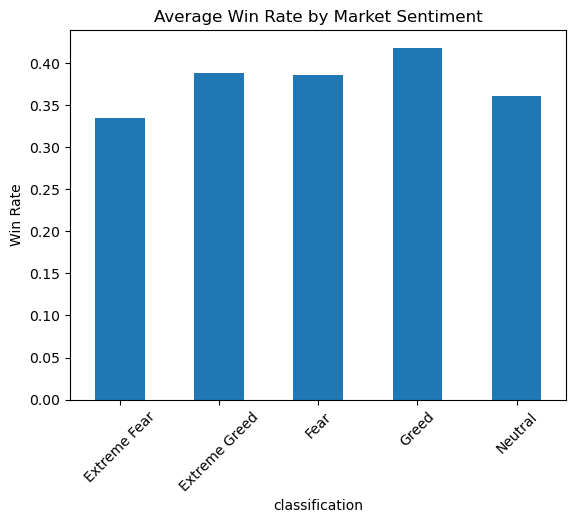

In [618]:
#Insight 2 — Higher Win Rate Does Not Equal Higher Profitability

mean_win.plot(kind='bar')
plt.title('Average Win Rate by Market Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=45)
plt.show()



#Insight 2: Greed Periods Show Higher Win Rates but Lower Profitability

Greed periods exhibit the highest win rate (~41.8%), while Fear periods show slightly lower win rates (~38.6%). 
Despite this, average profitability during Fear is significantly higher.

This suggests that profits during Fear regimes are driven by fewer but larger winning trades, 
whereas Greed regimes generate more frequent but smaller gains. 
Thus, consistency does not necessarily translate into higher overall returns.

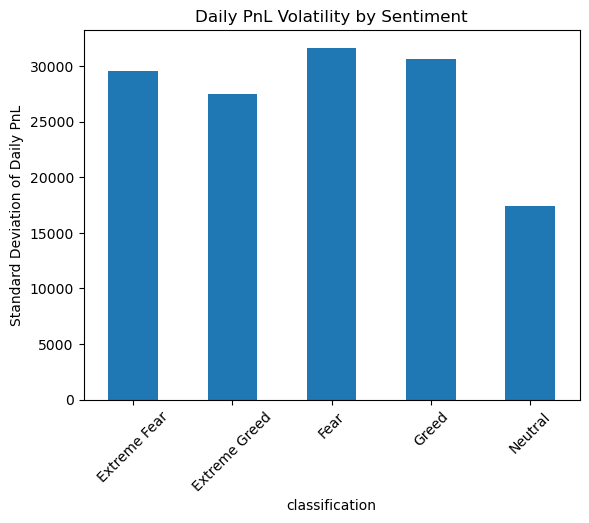

classification
Extreme Fear     -77308.420095
Extreme Greed   -132271.000000
Fear            -108604.496278
Greed           -358963.139984
Neutral         -113601.020138
Name: Closed PnL, dtype: float64

In [620]:
#Insight 3 — Greed Regimes Carry Higher Tail Risk

std_pnl.plot(kind='bar')
plt.title('Daily PnL Volatility by Sentiment')
plt.ylabel('Standard Deviation of Daily PnL')
plt.xticks(rotation=45)
plt.show()

min_pnl



#Insight 3: Greed Regimes Exhibit Elevated Downside Risk

Greed periods show the most extreme negative daily PnL (approximately -358,963), 
indicating substantial tail risk during optimistic market conditions.

While Fear periods demonstrate higher average returns, Greed periods expose traders 
to larger single-day downside events. Additionally, volatility is significantly elevated 
during strong sentiment regimes compared to Neutral markets.

This highlights that optimistic sentiment may encourage risk-taking behavior that increases exposure to extreme losses.
🎯 Why These 3 Insights Are Strong

# Part C — “Actionable output” (must-have)

# Strategy 1: Reduce Risk Exposure During Greed Regimes

Although Greed periods exhibit higher win rates, they also show the largest downside tail risk, 
including the most extreme negative daily PnL observed in the dataset.

Rule of Thumb:
During Greed regimes, traders should reduce position sizes or tighten stop-loss thresholds 
to protect against large adverse moves.

This approach maintains participation in profitable trades while mitigating exposure to 
rare but severe losses.

# Strategy 2 — Opportunistic Positioning During Fear

Fear has highest average PnL
Profits driven by large upside moves
Risk is high, but opportunity is high

Rule of Thumb:
During Fear periods, traders may maintain or moderately increase exposure, 
while actively managing volatility through diversification or dynamic position sizing.

This allows traders to capture large upside moves while managing elevated return volatility.

# Strategy 3: Allocate for Stability During Neutral Regimes

Neutral regimes exhibit lower volatility and more stable returns.

Rule of Thumb:
During Neutral sentiment, traders may adopt steady systematic strategies 
with consistent position sizing, as extreme tail risk appears limited.

This regime may be suitable for capital preservation strategies.


Strategy 1: Reduce Risk During Greed
Strategy 2: Opportunistic Exposure During Fear
(Strategy 3 optional)